<a href="https://colab.research.google.com/github/fablan-code/portfolio/blob/main/Trabajo_Final_BLANCO_IMAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

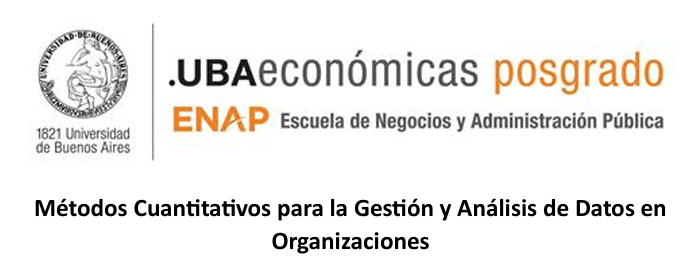

# **IMPLEMENTACIÓN DE MODELOS DE APRENDIZAJE AUTOMÁTICO**

Docentes: Mag. Domingo Pablo Brignardello, Prof. Alicia Fraquelli.

Alumno: Facundo Matías Blanco.


---



In [ ]:
#importación de las librerías para trabajar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as skl
import shap

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)


#Carga de los datos

In [ ]:
#traigo la database
df = pd.read_csv('/content/train.csv')
df.head(15)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [ ]:
df.shape

(891, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
#buscar nulos
df.isnull().sum().sort_values(ascending=False)

,0
Cabin,687
Age,177
Embarked,2
PassengerId,0
Name,0
Pclass,0
Survived,0
Sex,0
Parch,0
SibSp,0


#Análisis univariado

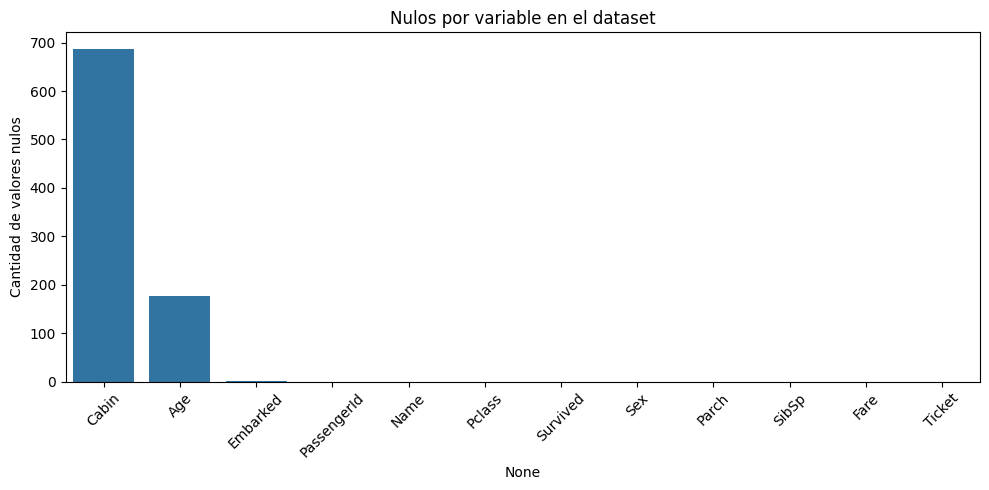

In [ ]:
#gráfico de nulos por variable
# Calcular cantidad de nulos por variable
nulos = df.isnull().sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=nulos.index, y=nulos.values)
plt.xticks(rotation=45)
plt.ylabel("Cantidad de valores nulos")
plt.title("Nulos por variable en el dataset")
plt.tight_layout()
plt.show()

In [ ]:
#cantidad de supervivientes
df['Survived'].value_counts()

,count
Survived,
0,549
1,342


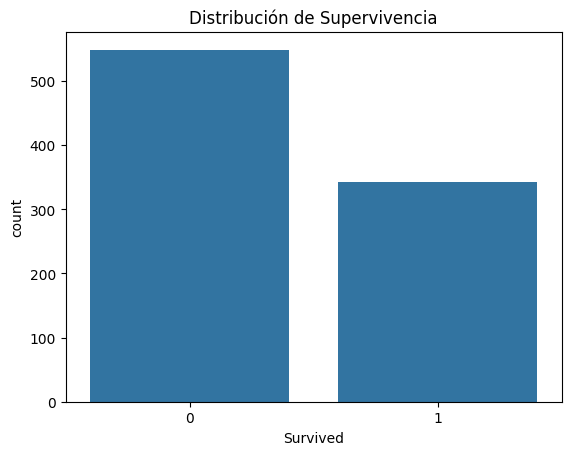

,proportion
Survived,
0,0.616162
1,0.383838


In [ ]:
sns.countplot(data=df, x='Survived')
plt.title("Distribución de Supervivencia")
plt.show()

df['Survived'].value_counts(normalize=True)

In [ ]:
#Comportamineto de las variables numéricas
numeric_cols = ['Age', 'SibSp', 'Parch', 'Fare']

df[numeric_cols].describe()

,Age,SibSp,Parch,Fare
count,714.000000,891.000000,891.000000,891.000000
mean,29.699118,0.523008,0.381594,32.204208
std,14.526497,1.102743,0.806057,49.693429
min,0.420000,0.000000,0.000000,0.000000
25%,20.125000,0.000000,0.000000,7.910400
50%,28.000000,0.000000,0.000000,14.454200
75%,38.000000,1.000000,0.000000,31.000000
max,80.000000,8.000000,6.000000,512.329200


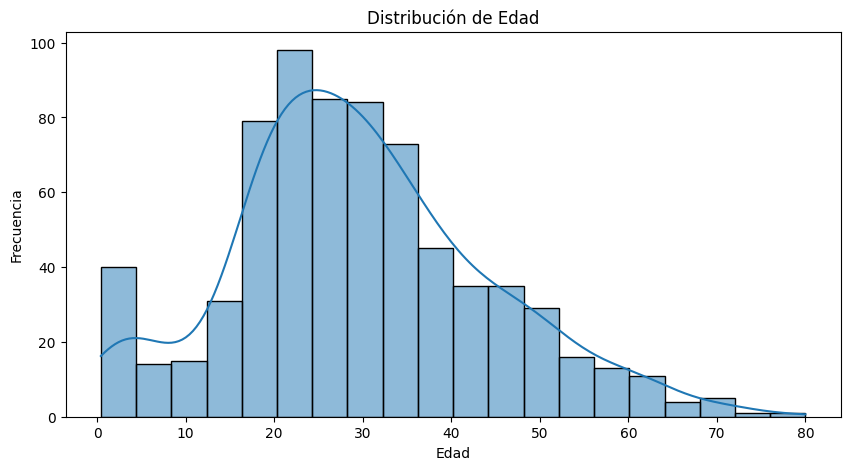

In [ ]:
#histograma de age
plt.figure(figsize=(10,5))
sns.histplot(df['Age'], kde=True)
plt.title("Distribución de Edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

Text(0.5, 1.0, 'Distribución de Número de Hermanos/Esposos')

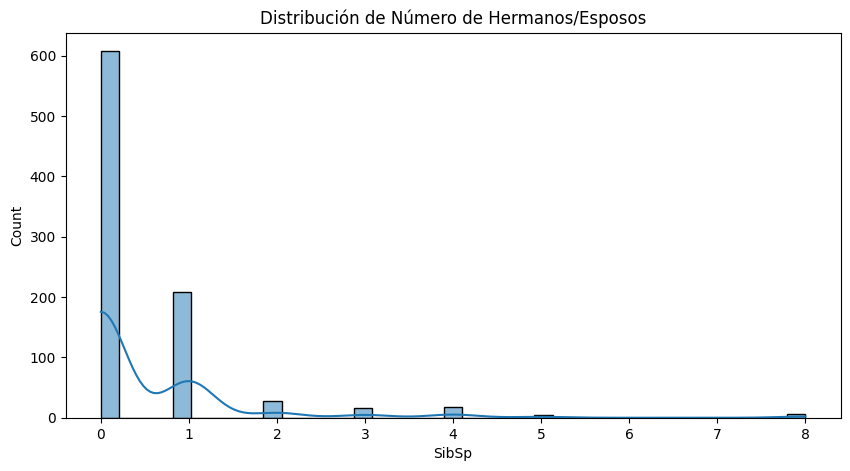

In [ ]:
#histograma de SibSp
plt.figure(figsize=(10,5))
sns.histplot(df['SibSp'], kde=True)
plt.title("Distribución de Número de Hermanos/Esposos")

Text(0.5, 1.0, 'Distribución de Número de Padres/Hijos')

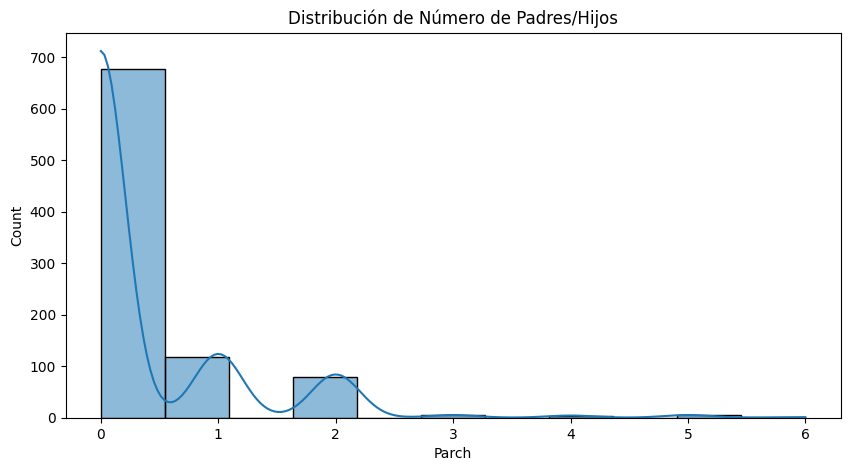

In [ ]:
#Histograma de Parch
plt.figure(figsize=(10,5))
sns.histplot(df['Parch'], kde=True)
plt.title("Distribución de Número de Padres/Hijos")

Text(0.5, 1.0, 'Distribución de Tarifa')

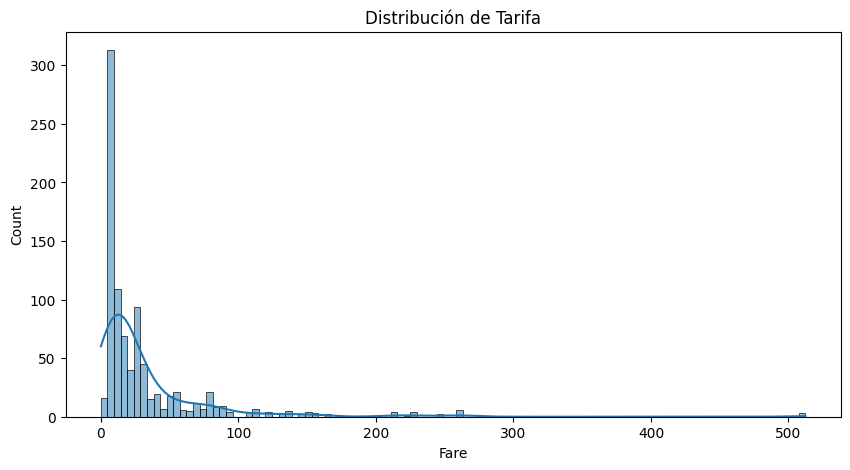

In [ ]:
#Histograma de Fare
plt.figure(figsize=(10,5))
sns.histplot(df['Fare'], kde=True)
plt.title("Distribución de Tarifa")

#Variables Categóricas

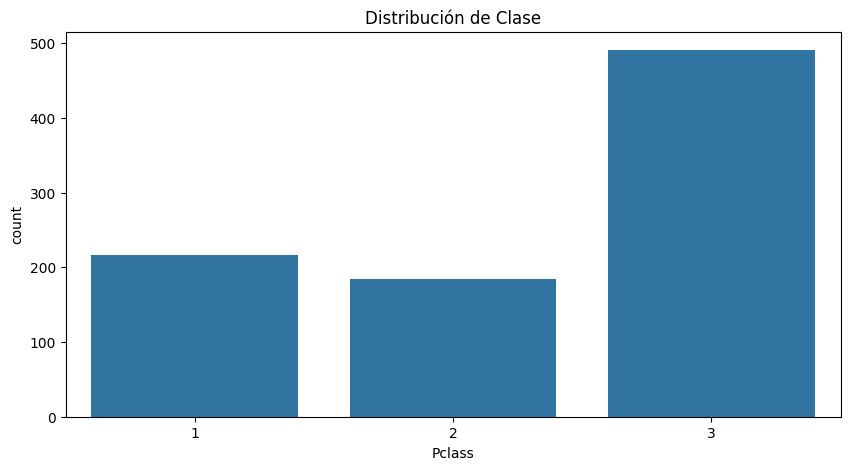

In [ ]:
#Histograma PClass
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Pclass')
plt.title("Distribución de Clase")
plt.show()

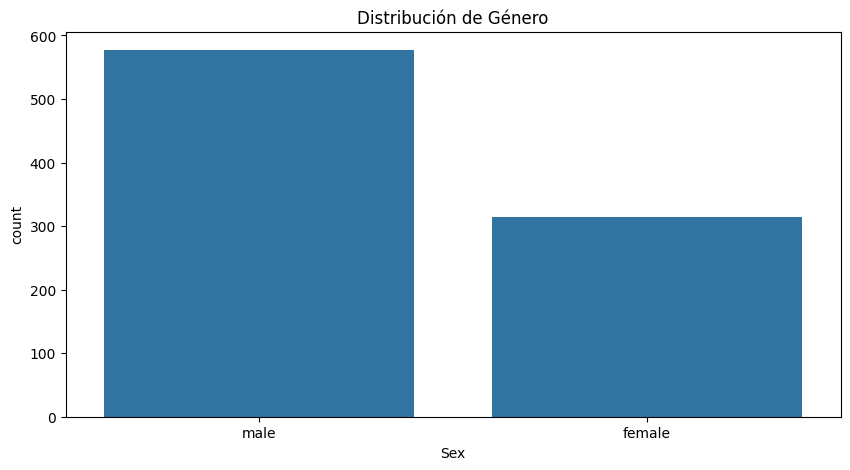

In [ ]:
#Histograma Sex
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Sex')
plt.title("Distribución de Género")
plt.show()

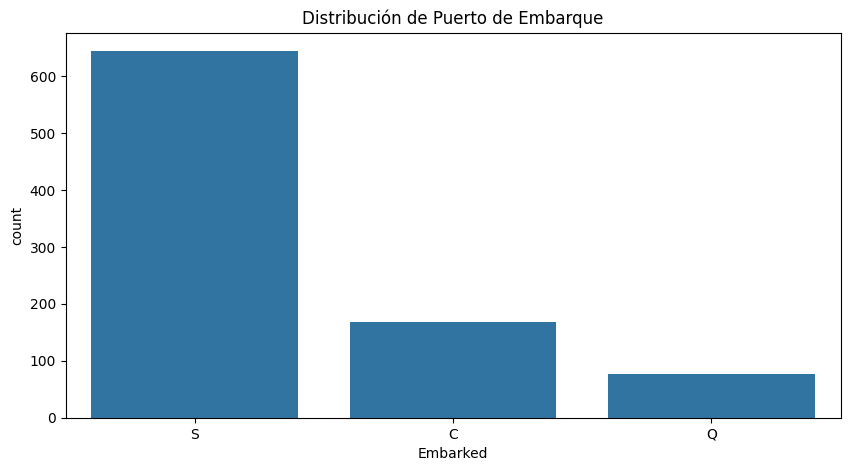

In [ ]:
#Histograma Embarked
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Embarked')
plt.title("Distribución de Puerto de Embarque")
plt.show()

#Análisis bivariado

In [ ]:
#Género vs Supervivencia
df.groupby("Sex")["Survived"].mean()

,Survived
Sex,
female,0.742038
male,0.188908


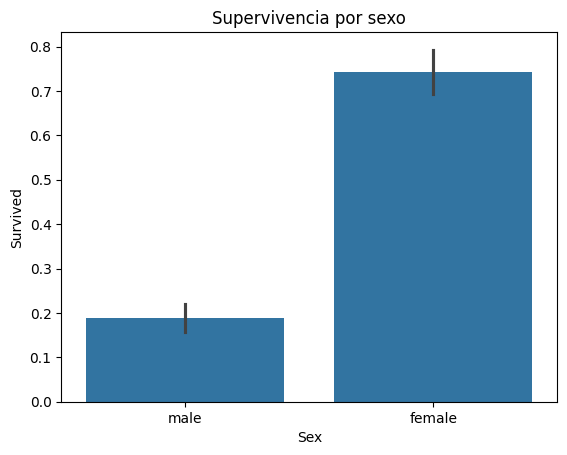

In [ ]:
sns.barplot(data=df, x="Sex", y="Survived")
plt.title("Supervivencia por sexo")
plt.show()


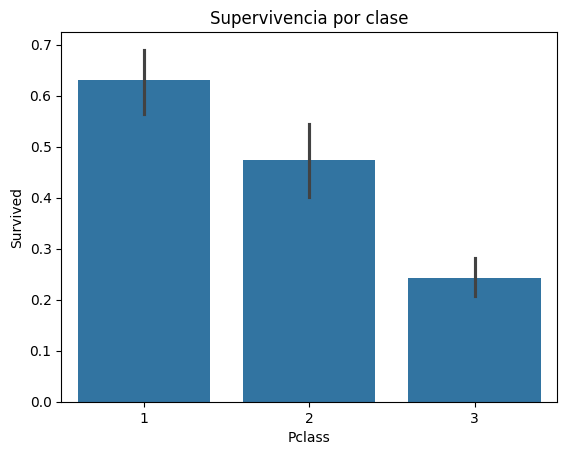

In [ ]:
sns.barplot(data=df, x="Pclass", y="Survived")
plt.title("Supervivencia por clase")
plt.show()

In [ ]:
df.groupby("Pclass")["Survived"].mean()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


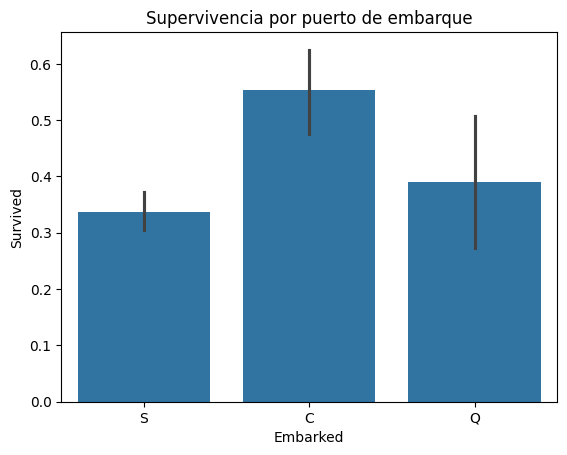

In [ ]:
sns.barplot(data=df, x="Embarked", y="Survived")
plt.title("Supervivencia por puerto de embarque")
plt.show()

In [ ]:
df.groupby("Embarked")["Survived"].mean()

,Survived
Embarked,
C,0.553571
Q,0.389610
S,0.336957


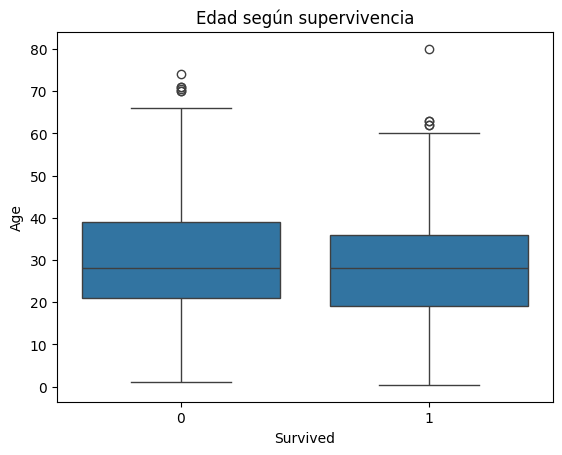

In [ ]:
sns.boxplot(data=df, x="Survived", y="Age")
plt.title("Edad según supervivencia")
plt.show()


In [ ]:
#edad vs supervivencia
df.groupby("Age")["Survived"].mean()

,Survived
Age,
0.42,1.0
0.67,1.0
0.75,1.0
0.83,1.0
0.92,1.0
...,...
70.00,0.0
70.50,0.0
71.00,0.0


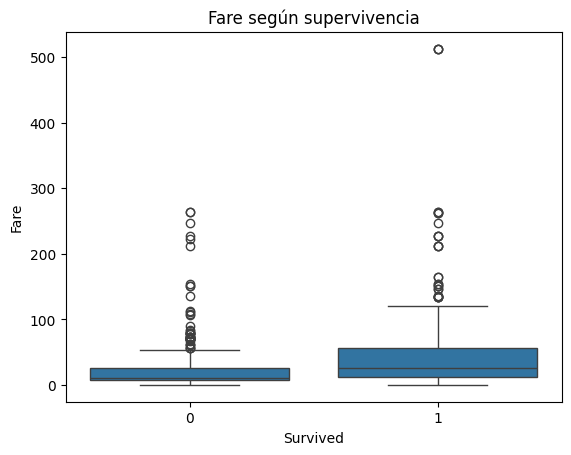

In [ ]:
# Fare vs Supervivencia
sns.boxplot(data=df, x="Survived", y="Fare")
plt.title("Fare según supervivencia")
plt.show()

In [ ]:
# Fare vs Supervivencia
df.groupby("Fare")["Survived"].mean()

,Survived
Fare,
0.0000,0.066667
4.0125,0.000000
5.0000,0.000000
6.2375,0.000000
6.4375,0.000000
...,...
227.5250,0.750000
247.5208,0.500000
262.3750,1.000000


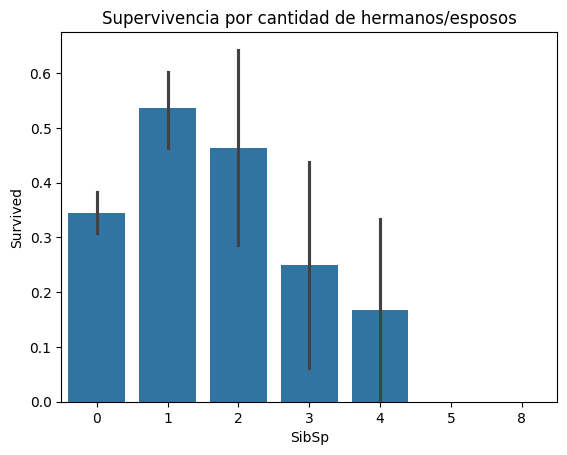

In [ ]:
# Familiares a bordo vs supervivencia
sns.barplot(data=df, x="SibSp", y="Survived")
plt.title("Supervivencia por cantidad de hermanos/esposos")
plt.show()

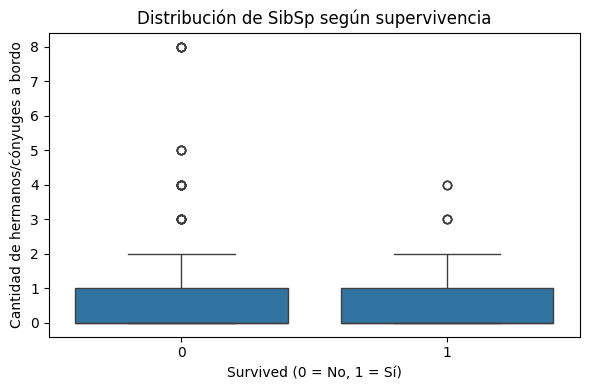

In [ ]:
df.groupby('Survived')['SibSp'].describe()

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Survived', y='SibSp')
plt.title("Distribución de SibSp según supervivencia")
plt.xlabel("Survived (0 = No, 1 = Sí)")
plt.ylabel("Cantidad de hermanos/cónyuges a bordo")
plt.tight_layout()
plt.show()

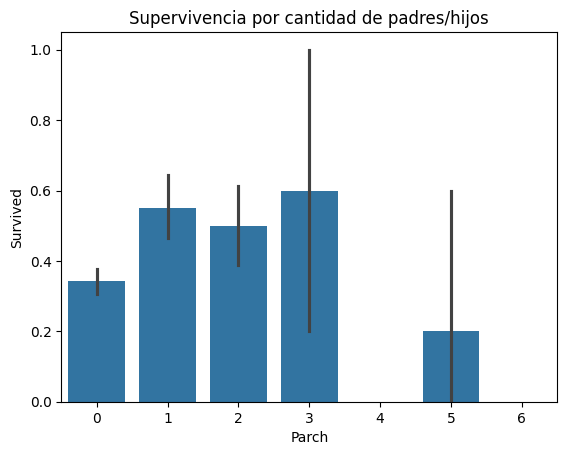

In [ ]:
#Parch vs supervivencia
sns.barplot(data=df, x="Parch", y="Survived")
plt.title("Supervivencia por cantidad de padres/hijos")
plt.show()

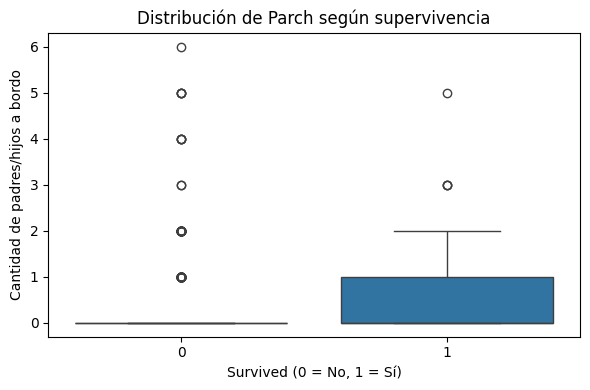

In [ ]:
df.groupby('Survived')['Parch'].describe()

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Survived', y='Parch')
plt.title("Distribución de Parch según supervivencia")
plt.xlabel("Survived (0 = No, 1 = Sí)")
plt.ylabel("Cantidad de padres/hijos a bordo")
plt.tight_layout()
plt.show()

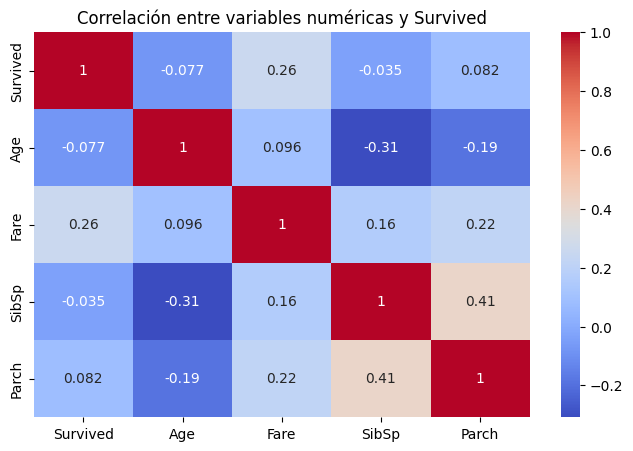

In [ ]:
plt.figure(figsize=(8,5))
sns.heatmap(df[['Survived','Age','Fare','SibSp','Parch']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlación entre variables numéricas y Survived")
plt.show()

# Tratamiento de los datos

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df = df.drop(columns=["PassengerId", "Ticket", "Cabin","Name"])

In [ ]:
# 1. Definición de las variables
var_num = ["Age", "SibSp", "Parch", "Fare"]
var_cat = ["Pclass", "Sex", "Embarked"]

In [ ]:
X = df[var_num + var_cat]
y = df["Survived"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
#Pipeline de tratamiento por tipo de variable
numeric_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="median")),("scaler", StandardScaler())])

# Creación del Pipeline del modelo

In [ ]:
categorical_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")),("onehot", OneHotEncoder(handle_unknown="ignore"))])

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, var_num),
        ("cat", categorical_transformer, var_cat)
    ]
)

In [ ]:
pipe = Pipeline(steps=[("preprocessor", preprocessor)])


In [ ]:
pipe.fit(X_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'SibSp', 'Parch',
                                                   'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Pclass', 'Sex',
                                                   'Embarked'])]))])

In [ ]:
pipe_clf=Pipeline(steps=[("preprocessor", preprocessor),("classifier", LogisticRegression(random_state=42))])

In [ ]:
pipe_clf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'SibSp', 'Parch',
                                                   'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Pclass', 'Sex',
                                                   'Embarked'])])),
                ('classifier', LogisticRegression(random_state=42))])

In [ ]:
y_pred = pipe_clf.predict(X_test)
y_prob = pipe_clf.predict_proba(X_test)[:,1]

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))


Accuracy: 0.8044692737430168
Precision: 0.7931034482758621
Recall: 0.6666666666666666
F1: 0.7244094488188977
AUC: 0.8426877470355731


In [ ]:
print(confusion_matrix(y_test, y_pred))

[[98 12]
 [23 46]]


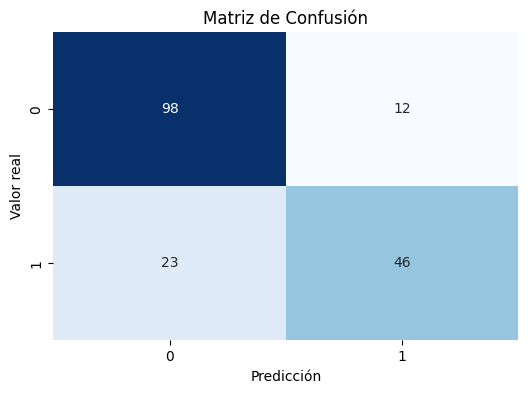

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de Confusión")
plt.show()

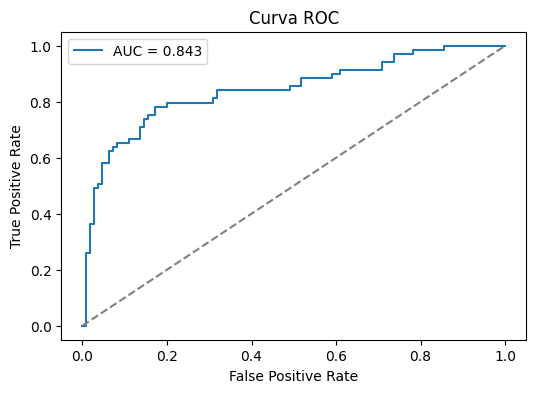

In [ ]:
# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_value = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc_value:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray",)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.show()

#Optimización de hiperparámetros

In [ ]:
pipe_to_tune = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(random_state=42))
])

In [ ]:
param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__solver": ["lbfgs", "liblinear"],
    "classifier__max_iter": [1000]
}

In [ ]:
grid = GridSearchCV(
    estimator=pipe_to_tune,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid.best_params_)
print("Mejor AUC en CV:", grid.best_score_)

Mejores hiperparámetros: {'classifier__C': 1, 'classifier__max_iter': 1000, 'classifier__solver': 'liblinear'}
Mejor AUC en CV: 0.8548846088893111


In [ ]:
best_model = grid.best_estimator_

y_pred_opt = best_model.predict(X_test)
y_proba_opt = best_model.predict_proba(X_test)[:, 1]

metrics_opt = {
    "Accuracy": accuracy_score(y_test, y_pred_opt),
    "Precision": precision_score(y_test, y_pred_opt),
    "Recall": recall_score(y_test, y_pred_opt),
    "F1": f1_score(y_test, y_pred_opt),
    "AUC": roc_auc_score(y_test, y_proba_opt)
}
metrics_opt


{'Accuracy': 0.8044692737430168,
 'Precision': 0.7931034482758621,
 'Recall': 0.6666666666666666,
 'F1': 0.7244094488188977,
 'AUC': np.float64(0.8426877470355731)}

AUC-ROC: 0.8426877470355731


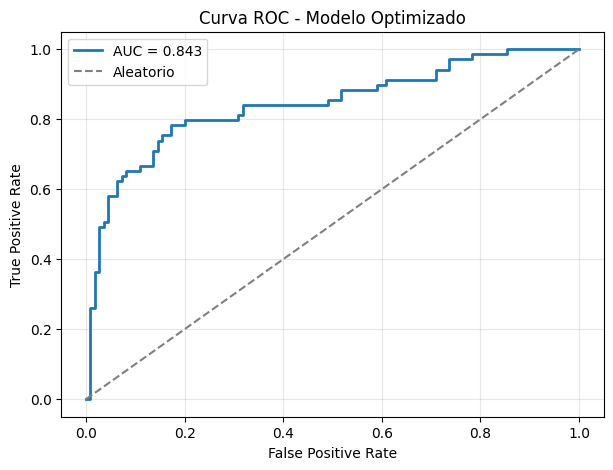

In [ ]:
# Calcular FPR, TPR y thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_proba_opt)

# Calcular AUC
auc_value = roc_auc_score(y_test, y_proba_opt)
print("AUC-ROC:", auc_value)

# Gráfico ROC
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_value:.3f}", linewidth=2)
plt.plot([0,1], [0,1], linestyle="--", color="gray", label="Aleatorio")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Modelo Optimizado")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


[[98 12]
 [23 46]]


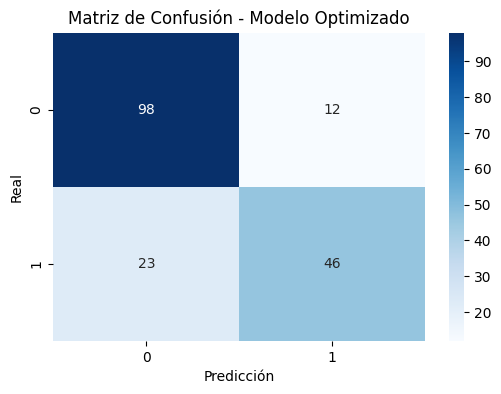

In [ ]:
# Matriz numérica
cm = confusion_matrix(y_test, y_pred_opt)
print(cm)

# Gráfico
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Modelo Optimizado")
plt.show()

In [ ]:
train_pred_proba = best_model.predict_proba(df[var_num + var_cat])[:, 1]
train_proba = best_model.predict_proba(X)[:, 1]


In [ ]:
train_proba.mean()

np.float64(0.38114116140085086)

#SHAP

In [ ]:
# pipeline optimizado
model = best_model

# Extraccion del preprocesador y el clasificador entrenados
pre = model.named_steps["preprocessor"]
clf = model.named_steps["classifier"]

# Transformación de X_train y X_test con el preprocesador ya ajustado
X_train_t = pre.transform(X_train)
X_test_t  = pre.transform(X_test)

# Recupero e los nombres de variables numéricas
num_features = var_num

# Recupero  los nombres de variables categóricas
ohe = pre.named_transformers_["cat"].named_steps["onehot"]
cat_features = ohe.get_feature_names_out(var_cat).tolist()

feature_names = num_features + cat_features

# Chequeo de consistencia
print("Cantidad de features transformadas:", X_train_t.shape[1])
print("Cantidad de variables:", len(feature_names))

Cantidad de features transformadas: 12
Cantidad de variables: 12


/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


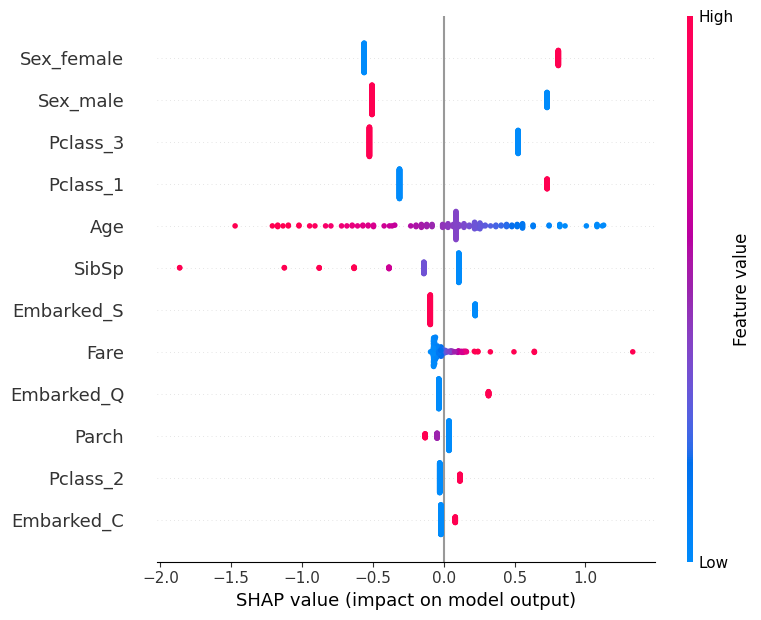

In [ ]:
#SHAP

explainer = shap.LinearExplainer(clf, X_train_t, feature_perturbation="interventional")

# Calculo de SHAP values sobre test
shap_values = explainer.shap_values(X_test_t)

# Resumen
shap.summary_plot(shap_values, features=X_test_t, feature_names=feature_names)